# Homework 03 — Python Fundamentals

Stage 03 practice: NumPy operations, pandas data loading & summary stats, and
reusable function design.

> Run this notebook from the `homework3/` directory (or open it in Jupyter) —
> the first cell auto-detects the project root so relative `data/` and `src/`
> paths resolve either way.

In [1]:
%matplotlib inline

# --- Imports ---
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Project root detection ---
# Jupyter runs the kernel from the notebook's directory (notebooks/), so step
# up one level to reach the homework3/ project root. Works either way.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
sys.path.insert(0, str(ROOT / "src"))  # make src/utils.py importable

print("Project root:", ROOT.resolve())

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/wangjing/bootcamp_Jesse_Wang/homework/homework3


## 1. NumPy Operations

Create an array, apply elementwise operations, and compare a Python loop with
NumPy's vectorized operations.

In [2]:
# Create a 1-D array and apply elementwise operations.
arr = np.arange(1, 11)          # [1, 2, ..., 10]
print("array       :", arr)

squared = arr ** 2              # elementwise square
print("squared     :", squared)

shifted = arr + 100             # elementwise add
print("plus 100    :", shifted)

evens = arr[arr % 2 == 0]       # boolean mask -> even values only
print("even values :", evens)

print(f"mean        : {arr.mean():.2f}")
print(f"std         : {arr.std():.2f}")

array       : [ 1  2  3  4  5  6  7  8  9 10]
squared     : [  1   4   9  16  25  36  49  64  81 100]
plus 100    : [101 102 103 104 105 106 107 108 109 110]
even values : [ 2  4  6  8 10]
mean        : 5.50
std         : 2.87


In [3]:
# Compare a Python loop vs NumPy's vectorized operation on 1,000,000 values.
N = 1_000_000
values = np.random.default_rng(0).random(N)   # seeded -> reproducible

start = time.perf_counter()
loop_sum = 0.0
for v in values:
    loop_sum += v
loop_time = time.perf_counter() - start

start = time.perf_counter()
np_sum = values.sum()
vec_time = time.perf_counter() - start

print(f"Python loop      : {loop_sum:.4f} in {loop_time:.4f}s")
print(f"NumPy vectorized : {np_sum:.4f} in {vec_time:.4f}s")
print(f"Speedup          : {loop_time / vec_time:.1f}x")

Python loop      : 500159.2565 in 0.1023s
NumPy vectorized : 500159.2565 in 0.0004s
Speedup          : 245.7x


## 2. Dataset Loading

Load the provided CSV and inspect it with `.info()` and `.head()`.

In [4]:
DATA_PATH = DATA_RAW / "starter_data.csv"
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH.resolve())
df.info()

Loaded: /Users/wangjing/bootcamp_Jesse_Wang/homework/homework3/data/raw/starter_data.csv
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  10 non-null     str  
 1   value     10 non-null     int64
 2   date      10 non-null     str  
dtypes: int64(1), str(2)
memory usage: 372.0 bytes


In [5]:
df.head()

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


## 3. Summary Statistics

Use `.describe()` to summarize the numeric columns.

In [6]:
df.describe()

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


## 4. Groupby Aggregation

Aggregate the numeric `value` column by `category`.

In [7]:
grouped = (
    df.groupby("category")["value"]
    .agg(count="count", mean="mean", sum="sum", min="min", max="max")
    .reset_index()
)
grouped

,category,count,mean,sum,min,max
0,A,4,11.500000,46,10,13
1,B,3,15.666667,47,14,18
2,C,3,27.666667,83,25,30


## 5. Save Outputs

Save the summary statistics to `data/processed/`.

In [8]:
# Ensure the output directory exists.
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Main deliverable: per-category summary.
grouped.to_csv(DATA_PROCESSED / "summary.csv", index=False)

# Extra: overall descriptive statistics.
df.describe().to_csv(DATA_PROCESSED / "summary_describe.csv")

print("Saved:")
print("  -", (DATA_PROCESSED / "summary.csv").resolve())
print("  -", (DATA_PROCESSED / "summary_describe.csv").resolve())

Saved:
  - /Users/wangjing/bootcamp_Jesse_Wang/homework/homework3/data/processed/summary.csv
  - /Users/wangjing/bootcamp_Jesse_Wang/homework/homework3/data/processed/summary_describe.csv


## 6. Reusable Function

The summary logic lives in `src/utils.py` so it can be reused anywhere. Import
it here and confirm it produces the same results.

In [9]:
from utils import get_summary_stats, aggregate_by_category

# Descriptive stats, now computed by the imported helper.
get_summary_stats(df)

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


In [10]:
# Groupby aggregation, also reusable:
aggregate_by_category(df, group_col="category", value_col="value")

,category,count,mean,sum,min,max
0,A,4,11.500000,46,10,13
1,B,3,15.666667,47,14,18
2,C,3,27.666667,83,25,30


## Bonus: Basic Plot

Visualize the mean value per category and save the figure to `data/processed/`.

Saved plot: /Users/wangjing/bootcamp_Jesse_Wang/homework/homework3/data/processed/category_means.png


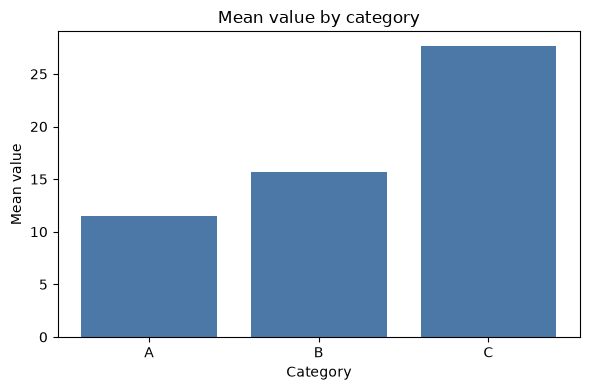

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(grouped["category"], grouped["mean"], color="#4C78A8")
ax.set_xlabel("Category")
ax.set_ylabel("Mean value")
ax.set_title("Mean value by category")
fig.tight_layout()

plot_path = DATA_PROCESSED / "category_means.png"
fig.savefig(plot_path, dpi=120)
print("Saved plot:", plot_path.resolve())

In [12]:
# Sanity check: read back the saved summary.csv.
pd.read_csv(DATA_PROCESSED / "summary.csv")

,category,count,mean,sum,min,max
0,A,4,11.500000,46,10,13
1,B,3,15.666667,47,14,18
2,C,3,27.666667,83,25,30
